In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Saare available datasets ke naam
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [9]:
df = sns.load_dataset('fmri')
df.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


In [11]:
df.shape

(1064, 5)

In [12]:
df.isnull().sum()

subject      0
timepoint    0
event        0
region       0
signal       0
dtype: int64

In [14]:
y = df['signal']
y

0      -0.017552
1      -0.080883
2      -0.081033
3      -0.046134
4      -0.037970
          ...   
1059    0.018165
1060   -0.029130
1061   -0.004939
1062   -0.025367
1063   -0.006899
Name: signal, Length: 1064, dtype: float64

In [15]:
df = df.drop(columns=['signal'])
df.head()

,subject,timepoint,event,region
0,s13,18,stim,parietal
1,s5,14,stim,parietal
2,s12,18,stim,parietal
3,s11,18,stim,parietal
4,s10,18,stim,parietal


In [19]:
# drop_first=True multicollinearity se bachata hai
df = pd.get_dummies(df, columns=['event', 'region'], drop_first=True, dtype=int)
df.head()

,subject,timepoint,event_stim,region_parietal
0,s13,18,1,1
1,s5,14,1,1
2,s12,18,1,1
3,s11,18,1,1
4,s10,18,1,1


In [23]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder ka object banayein
le = LabelEncoder()

# 'subject' column ko encode karein
df['subject'] = le.fit_transform(df['subject'])

df.head()

,subject,timepoint,event_stim,region_parietal
0,5,18,1,1
1,9,14,1,1
2,4,18,1,1
3,3,18,1,1
4,2,18,1,1


In [24]:
# Classes dekhne ke liye (kaunsa index kis subject ko mila)
print(le.classes_)

# Wapas text me convert karne ke liye (Inverse transform)
# df['subject'] = le.inverse_transform(df['subject'])

['s0' 's1' 's10' 's11' 's12' 's13' 's2' 's3' 's4' 's5' 's6' 's7' 's8' 's9']


In [29]:
from sklearn.cluster import KMeans

# 1. KMeans initialize karein
kmeans = KMeans(n_clusters=3, random_state=42)

# 2. Fit karke labels assign karein
df['cluster'] = kmeans.fit_predict(df)

# Check results
df.head()

,subject,timepoint,event_stim,region_parietal,cluster
0,5,18,1,1,1
1,9,14,1,1,0
2,4,18,1,1,1
3,3,18,1,1,1
4,2,18,1,1,1


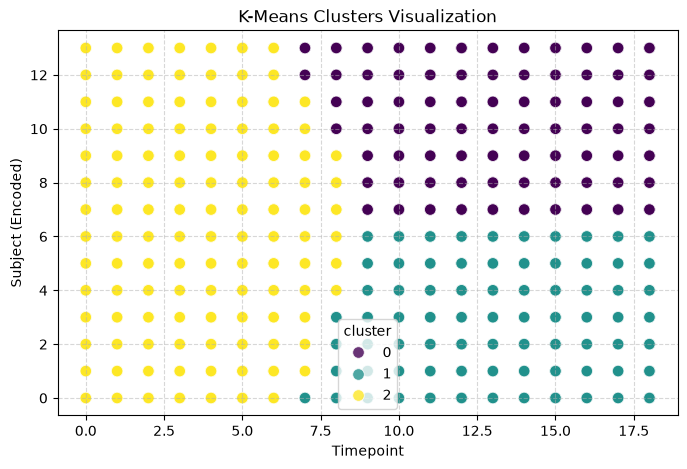

In [31]:
plt.figure(figsize=(8, 5))

# Scatter plot: x-axis par 'timepoint' aur y-axis par 'subject'
sns.scatterplot(
    data=df, 
    x='timepoint', 
    y='subject', 
    hue='cluster', 
    palette='viridis', 
    s=70, 
    alpha=0.8
)

plt.title('K-Means Clusters Visualization')
plt.xlabel('Timepoint')
plt.ylabel('Subject (Encoded)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

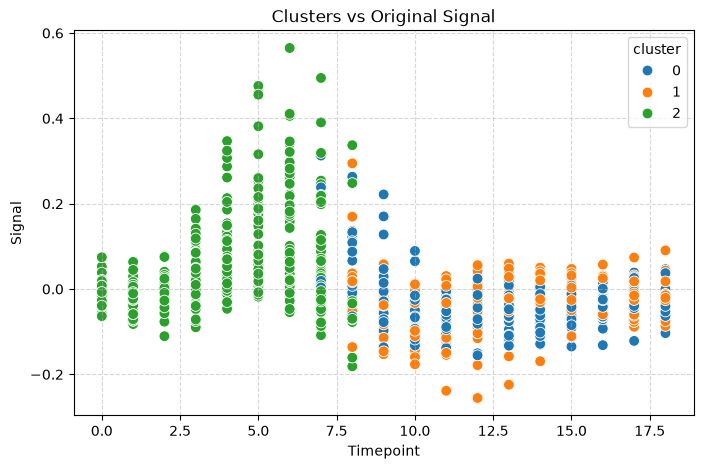

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df['timepoint'], 
    y=y, 
    hue=df['cluster'], 
    palette='tab10', 
    s=60
)

plt.title('Clusters vs Original Signal')
plt.xlabel('Timepoint')
plt.ylabel('Signal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

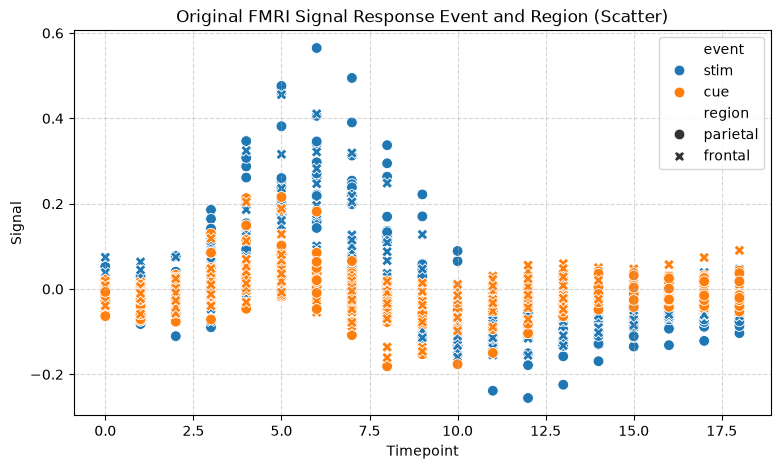

In [34]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=sns.load_dataset('fmri'),
    x='timepoint',
    y='signal',
    hue='event',
    style='region',
    markers=True,
    s=60
)

plt.title('Original FMRI Signal Response Event and Region (Scatter)')
plt.xlabel('Timepoint')
plt.ylabel('Signal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()